# Feature engineering

In [90]:
# Librerias 
import pandas as pd
import numpy as np
import joblib
import sys 

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, precision_recall_curve
from sklearn.metrics import ConfusionMatrixDisplay

In [91]:
# Caarga de datos 
try:
    path = "../data/raw/clinical_trial_data.csv"
    df = pd.read_csv(path)
    print(df.sample(10))
except:
    print("Error, datos no encontrados en la ruta ")
    sys.exit()




    Patient_ID  Age Gender   BMI  Systolic_BP  Glucose_Level Treatment_Arm  \
460    PT-0461   78      F  24.7        135.0          110.6        Drug_X   
361    PT-0362   73      M  30.7        131.0           95.5        Drug_X   
360    PT-0361   61      F  23.7        107.0           98.8       Placebo   
282    PT-0283   74      F  26.8        142.0           93.1        Drug_X   
795    PT-0796   67      F  40.1        121.0          135.9       Placebo   
13     PT-0014   32      F  29.8        119.0           57.2        Drug_X   
656    PT-0657   55      F  25.3        117.0           60.6        Drug_X   
621    PT-0622   60      F  32.1        107.0           96.3        Drug_X   
977    PT-0978   25      F  31.0        106.0           80.9       Placebo   
773    PT-0774   66      M  25.1        109.0          116.8       Placebo   

     Dropped_Out  
460            0  
361            0  
360            1  
282            1  
795            1  
13             0  
656     

In [92]:
# Ingeniería de datos 

X = df.drop(['Dropped_Out','Patient_ID'], axis = 1)
y = df['Dropped_Out']

In [93]:
# Separación y entrenamiento 

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state =42, stratify = y) 
print(f"Total de paciente, set de entrenamiento {len(X_train)}, set de prueba {len(X_test)}")

Total de paciente, set de entrenamiento 800, set de prueba 200


In [94]:
# Data engineering 
numeric_c = ['Age', 'BMI', 'Systolic_BP', 'Glucose_Level']
categorical_c = ['Gender', 'Treatment_Arm']

preprocessor = ColumnTransformer(
    transformers= [
        ('num', StandardScaler(), numeric_c),
        ('cat', OneHotEncoder(drop = 'first',sparse_output = False), categorical_c)
    ], 
    remainder= 'passthrough'
)



In [95]:
# Pipeline 

pipeline = Pipeline(
    steps =[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(class_weight= 'balanced', random_state= 42, max_iter=1000))
    ]
)

In [96]:
# Cross validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state= 42)

param_grid = {
    'classifier__C':[0.01,0.1,1,10],
    
}

grid_search = GridSearchCV(pipeline, param_grid, cv = cv_strategy, scoring= 'roc_auc', n_jobs= -1)

grid_search.fit(X_train, Y_train)

best_model = grid_search.best_estimator_
best_params = grid_search.best_params_


print(f"Los mejores hiperparámetros para el modelo de regresión logistica son \n{best_params}")
    

Los mejores hiperparámetros para el modelo de regresión logistica son 
{'classifier__C': 10}


In [97]:
# Optimización del umbral clínico 

y_scores = best_model.predict_proba(X_test)[:,1]

precisions, recalls, thresholds = precision_recall_curve(Y_test, y_scores)

f2_scores = (5 * precisions[:-1] * recalls[:-1]) / ((4 * precisions[:-1]) + recalls[:-1])

optimal_idx = np.nanargmax(f2_scores)
optimal_thresholds = thresholds[optimal_idx]

print(f"El umbral óptima calculado fue de = {optimal_thresholds:.3f}")

El umbral óptima calculado fue de = 0.204


In [98]:
# Evaluación y persistencia 

y_pred_custom = (y_scores >= optimal_thresholds).astype(int)

print("\nREPORTE DE CLASIFICACIÓN (umbral ajustado):")
print(classification_report(Y_test, y_pred_custom))


roc_auc = roc_auc_score(Y_test, y_scores)
print(f"ROC-AUC Score: {roc_auc:.3f}")

print("\n Matriz de confusión")
cm = confusion_matrix(Y_test, y_pred_custom)
print(f"Verdaderos Negativos (Terminan y acertamos): {cm[0][0]}")
print(f"Falsos Positivos (Falsa Alarma): {cm[0][1]}")
print(f"Falsos Negativos (PELIGRO - Abandonó y no avisamos): {cm[1][0]}")
print(f"Verdaderos Positivos (Abandono detectado a tiempo): {cm[1][1]}")




REPORTE DE CLASIFICACIÓN (umbral ajustado):
              precision    recall  f1-score   support

           0       1.00      0.12      0.22        66
           1       0.70      1.00      0.82       134

    accuracy                           0.71       200
   macro avg       0.85      0.56      0.52       200
weighted avg       0.80      0.71      0.62       200

ROC-AUC Score: 0.783

 Matriz de confusión
Verdaderos Negativos (Terminan y acertamos): 8
Falsos Positivos (Falsa Alarma): 58
Falsos Negativos (PELIGRO - Abandonó y no avisamos): 0
Verdaderos Positivos (Abandono detectado a tiempo): 134


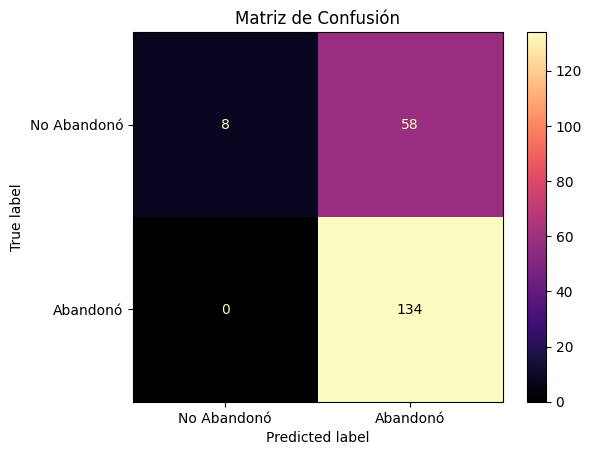

In [99]:
# Visualización de la matriz de confusión

ConfusionMatrixDisplay.from_predictions(Y_test, y_pred_custom, 
                                        display_labels=['No Abandonó', 'Abandonó'],
                                        cmap='magma')
plt.title('Matriz de Confusión')
plt.show()

In [100]:
joblib.dump(best_model, '../src/models/clinical_oracle_pipeline.pkl')

['../src/models/clinical_oracle_pipeline.pkl']

# Conclusiones

En esta fase, transitamos de la ingeniería de datos a la predicción clínica, construyendo un modelo robusto y alineado a los objetivos de retención del ensayo clínico.

1. Arquitectura hermética y prevención de fugas de datos (MLOps)
* Se encapsuló el preprocesamiento (StandardScaler, OneHotEncoder) y el modelo (LogisticRegression) dentro de un Pipeline de scikit-learn.
* La búsqueda de hiperparámetros (GridSearchCV) se ejecutó bajo una estrategia de Validación Cruzada Estratificada de 5 pliegues (StratifiedKFold). Esta arquitectura garantizó que el escalamiento estadístico se recalculara por cada pliegue de entrenamiento, erradicando al 100% el Data Leakage o fuga de información futura.

2. Desempeño del modelo base y regularización
* El algoritmo determinó que el hiperparámetro óptimo para la regularización **$L_2$** es C=10, lo que indica que las características de entrada (biomarcadores) poseen una alta pureza predictiva y no requieren de fuerte penalización matemática para evitar el sobreajuste.
* El modelo base logró un ROC-AUC de 0.783, confirmando una capacidad discriminatoria sólida para separar pacientes estables de aquellos en riesgo metabólico o de tratamiento.

3. Calibración clínica del umbral (Business Optimization)
* El problema: El umbral por defecto (50%) en algoritmos de clasificación es inaceptable en Clinical Development, donde el costo de un paciente perdido (Drop-out) es crítico.
* La solución: Se implementó una optimización de la curva Precision-Recall utilizando la métrica **$F_2$**, la cual pondera el Recall (sensibilidad) con el doble de peso que la precisión.
* El impacto de negocio: El umbral clínico óptimo se ajustó al 20.4% (0.204). Esta calibración estratégica logró un Recall del 100% para la clase minoritaria. Se erradicaron por completo los Falsos Negativos (cero pacientes perdidos sin alerta previa). Se asumió conscientemente una tasa de 58 Falsos Positivos, justificando que el costo operativo de una llamada médica preventiva es matemáticamente despreciable en comparación con la pérdida de datos y recursos de un paciente en el ensayo.